In [1]:
# Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-17 16:58:03 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [ ]:
pip install seaborn matplotlib plotly scikit-learn

In [3]:
# Training Pipeline
from src.models.train import F1ModelTrainer
from src.models.evaluate import ModelEvaluator

trainer = F1ModelTrainer()
evaluator = ModelEvaluator()

In [4]:
# Train All Models
results = trainer.train_all_models(years=[2021, 2022, 2023, 2024, 2025])

print("Training Results:")
for target, models in results.items():
    print(f"\n{target}:")
    for model_type, path in models.items():
        print(f"  {model_type}: {path}")

2026-05-17 16:59:40 [debug    ] sql_query_executing            parameters={'year_0': 2021, 'year_1': 2022, 'year_2': 2023, 'year_3': 2024, 'year_4': 2025} statement='\n        SELECT \n            f.*,\n            r.year,\n            r.round,\n            r.date as race_date\n        FROM driver_race_features f\n        JOIN races r ON f.race_id = r.race_id\n        WHE'
2026-05-17 16:59:45 [debug    ] database_transaction_committed
2026-05-17 16:59:45 [info     ] training_data_loaded           features=26 rows=2278 years=[2021, 2022, 2023, 2024, 2025]
2026-05-17 16:59:45 [info     ] SMOTE applied for winner: 3462 samples
2026-05-17 16:59:45 [info     ] SMOTE applied for top3: 3098 samples
2026-05-17 16:59:45 [info     ] features_prepared              features=26 test_size=456 train_size=1822
2026-05-17 16:59:45 [info     ] Training winner prediction models...
2026-05-17 16:59:45 [info     ] logistic_regression_trained    target=winner
2026-05-17 16:59:45 [info     ] model_saved     

d:\formula1-race-prediction-project\notebooks\..\src\models\train.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(X.median())


2026-05-17 16:59:45 [info     ] random_forest_trained          target=winner
2026-05-17 16:59:46 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_winner_20260517_135945.pkl target=winner
2026-05-17 16:59:46 [info     ] xgboost_trained                target=winner
2026-05-17 16:59:46 [info     ] model_saved                    model=xgboost path=artifacts\models\xgboost_winner_20260517_135946.pkl target=winner
2026-05-17 16:59:46 [info     ] Training top3 prediction models...


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 16:59:46 [info     ] logistic_regression_trained    target=top3
2026-05-17 16:59:46 [info     ] model_saved                    model=logistic_regression path=artifacts\models\logistic_regression_top3_20260517_135946.pkl target=top3
2026-05-17 16:59:46 [info     ] random_forest_trained          target=top3
2026-05-17 16:59:47 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_top3_20260517_135946.pkl target=top3
2026-05-17 16:59:47 [info     ] xgboost_trained                target=top3


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:59:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 16:59:47 [info     ] model_saved                    model=xgboost path=artifacts\models\xgboost_top3_20260517_135947.pkl target=top3
2026-05-17 16:59:47 [info     ] Training points prediction models...
2026-05-17 16:59:47 [info     ] linear_regression_trained     
2026-05-17 16:59:47 [info     ] model_saved                    model=linear_regression path=artifacts\models\linear_regression_points_20260517_135947.pkl target=points
2026-05-17 16:59:47 [info     ] random_forest_regressor_trained
2026-05-17 16:59:48 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_points_20260517_135947.pkl target=points
2026-05-17 16:59:48 [info     ] pipeline_metrics               duration_seconds=8.231073 errors=[] pipeline_name=model_training records_failed=0 records_processed=0 status=completed success_rate=0
2026-05-17 16:59:48 [info     ] training_pipeline_complete    
Training Results:

is_winner:
  logistic_regression: {'model': LogisticR

In [7]:

comparison_data = []

for target, models in results.items():
    if target == 'is_winner' or target == 'is_top3':
        for model_name, model_data in models.items():
            # Check if model_data is a dict with 'metrics' key (new structure)
            if isinstance(model_data, dict) and 'metrics' in model_data:
                metrics = model_data['metrics']
                comparison_data.append({
                    'target': target,
                    'model': model_name,
                    'accuracy': metrics.get('accuracy', 0),
                    'precision': metrics.get('precision', 0),
                    'recall': metrics.get('recall', 0),
                    'f1_score': metrics.get('f1_score', 0)
                })
            # Fallback for old structure (direct metrics)
            elif isinstance(model_data, dict) and 'accuracy' in model_data:
                comparison_data.append({
                    'target': target,
                    'model': model_name,
                    'accuracy': model_data.get('accuracy', 0),
                    'precision': model_data.get('precision', 0),
                    'recall': model_data.get('recall', 0),
                    'f1_score': model_data.get('f1_score', 0)
                })
            else:
                print(f"Warning: Unexpected structure for {target}.{model_name}: {type(model_data)}")

comparison = pd.DataFrame(comparison_data)

print("Comparison DataFrame created:")
print(comparison)
print("\nColumns:", comparison.columns.tolist())

Comparison DataFrame created:
      target                model  accuracy  precision    recall  f1_score
0  is_winner  logistic_regression  0.853070   0.255556  1.000000  0.407080
1  is_winner        random_forest  0.921053   0.341463  0.608696  0.437500
2  is_winner              xgboost  0.949561   0.500000  0.478261  0.488889
3    is_top3  logistic_regression  0.864035   0.529412  0.913043  0.670213
4    is_top3        random_forest  0.899123   0.623656  0.840580  0.716049
5    is_top3              xgboost  0.918860   0.710526  0.782609  0.744828

Columns: ['target', 'model', 'accuracy', 'precision', 'recall', 'f1_score']


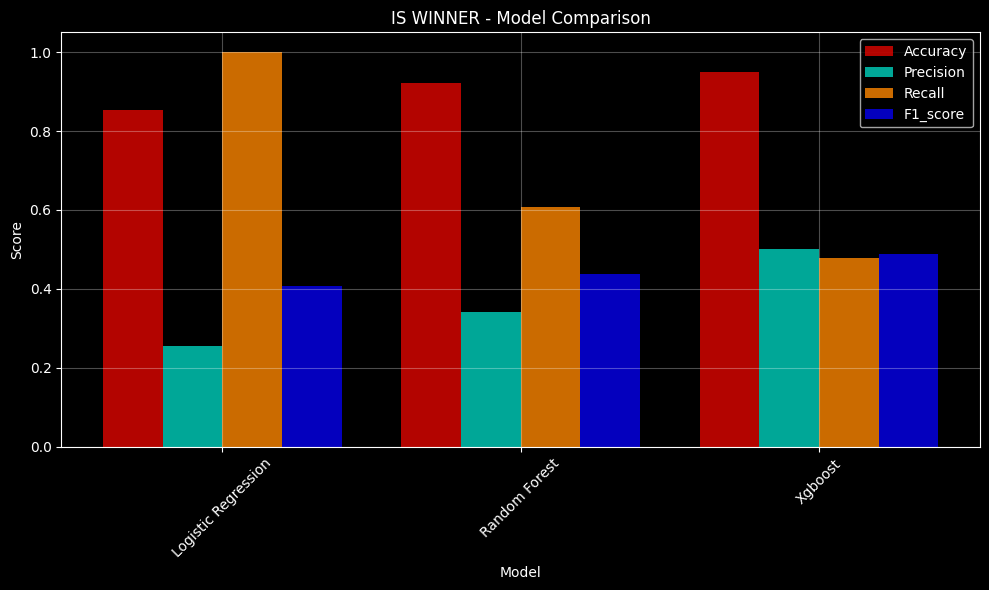

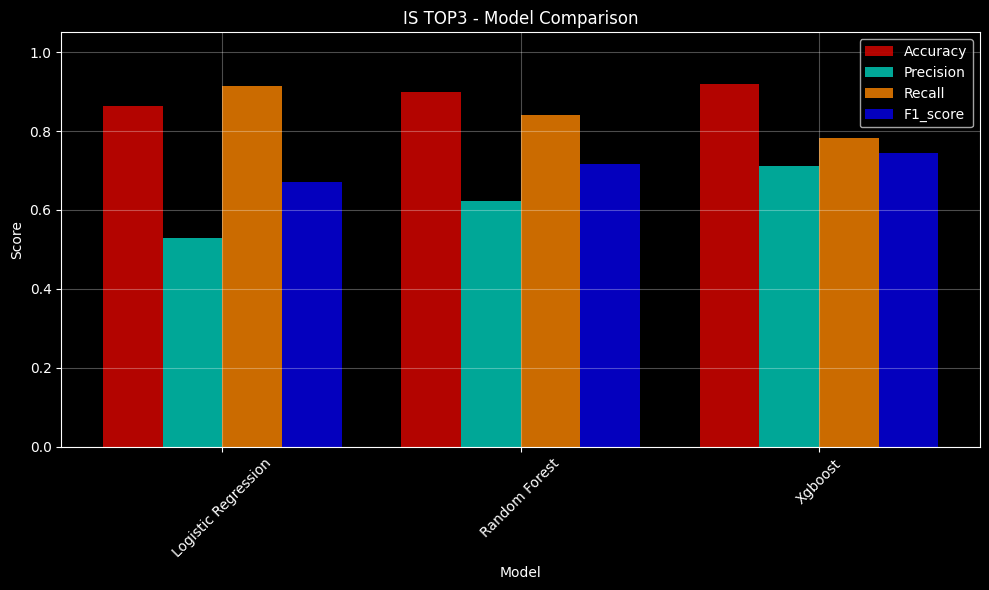

In [8]:
# Plot for each target
for target in ['is_winner', 'is_top3']:
    df_target = comparison[comparison['target'] == target]
    
    if not df_target.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        metrics = ['accuracy', 'precision', 'recall', 'f1_score']
        x = np.arange(len(df_target['model']))
        width = 0.2
        
        colors = ['#e10600', '#00d2be', '#ff8700', '#0600ef']
        
        for i, (metric, color) in enumerate(zip(metrics, colors)):
            ax.bar(x + i * width, df_target[metric], width, label=metric.capitalize(), color=color, alpha=0.8)
        
        ax.set_xlabel('Model')
        ax.set_ylabel('Score')
        ax.set_title(f'{target.upper().replace("_", " ")} - Model Comparison')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(df_target['model'].str.replace('_', ' ').str.title())
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

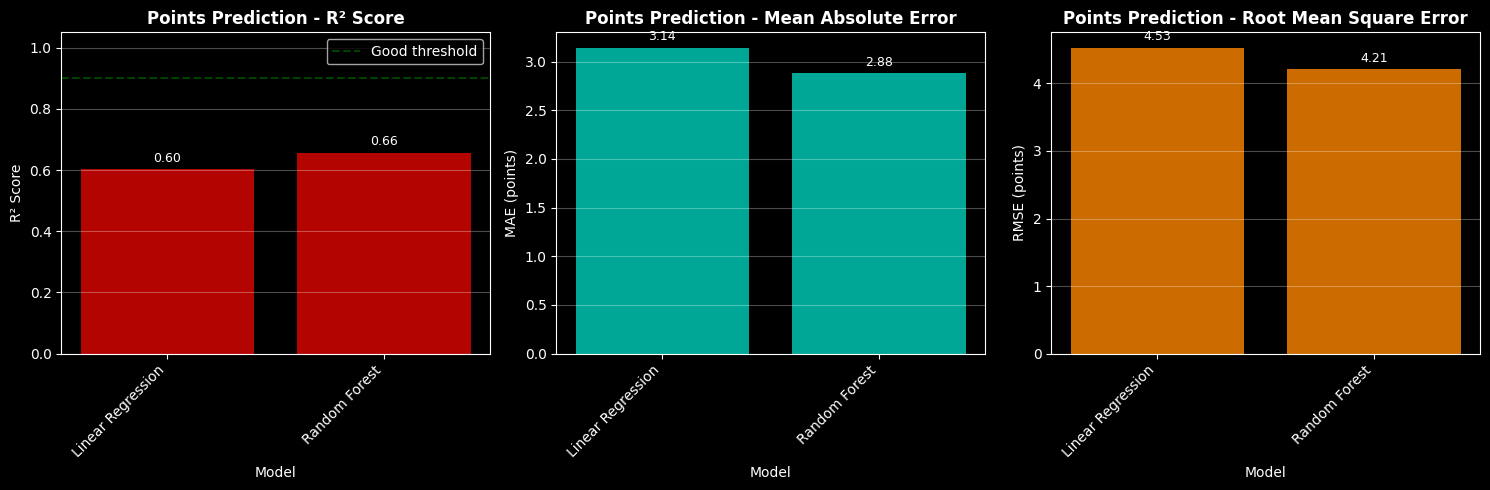


POINTS PREDICTION SUMMARY
            model  R² (R2)      MAE     RMSE
Linear Regression 0.602413 3.143745 4.530491
    Random Forest 0.656974 2.879485 4.208166


In [10]:
# Points prediction comparison
points_data = []
for model_name, model_data in results['points'].items():
    # Extract metrics from the nested structure
    if isinstance(model_data, dict) and 'metrics' in model_data:
        metrics = model_data['metrics']
        points_data.append({
            'model': model_name.replace('_', ' ').title(),
            'R² (R2)': metrics.get('r2', 0),
            'MAE': metrics.get('mae', 0),
            'RMSE': metrics.get('rmse', 0)
        })
    else:
        # Fallback for old structure
        points_data.append({
            'model': model_name.replace('_', ' ').title(),
            'R² (R2)': model_data.get('r2', 0),
            'MAE': model_data.get('mae', 0),
            'RMSE': model_data.get('rmse', 0)
        })

points_df = pd.DataFrame(points_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Plot
bars1 = axes[0].bar(points_df['model'], points_df['R² (R2)'], color='#e10600', alpha=0.8)
axes[0].set_title('Points Prediction - R² Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Good threshold')
axes[0].legend()

# MAE Plot
bars2 = axes[1].bar(points_df['model'], points_df['MAE'], color='#00d2be', alpha=0.8)
axes[1].set_title('Points Prediction - Mean Absolute Error', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (points)')

# RMSE Plot
bars3 = axes[2].bar(points_df['model'], points_df['RMSE'], color='#ff8700', alpha=0.8)
axes[2].set_title('Points Prediction - Root Mean Square Error', fontsize=12, fontweight='bold')
axes[2].set_ylabel('RMSE (points)')

for ax in axes:
    ax.set_xlabel('Model', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax = bar.axes
        ax.annotate(f'{height:.2f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("POINTS PREDICTION SUMMARY")
print("="*60)
print(points_df.to_string(index=False))

In [11]:
# Check what's in results['is_winner']['xgboost']
print(type(results['is_winner']['xgboost']))
print(results['is_winner']['xgboost'])

<class 'dict'>
{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...), 'metrics': {'target': 'winner', 'accuracy': 0.9495614035087719, 'precision': 0.5, 'recall': 0.4782608695652174, 'f1_score': 0.4888888888888889, 'confusion_matrix': [[422, 11], [12, 11]], 'classificat

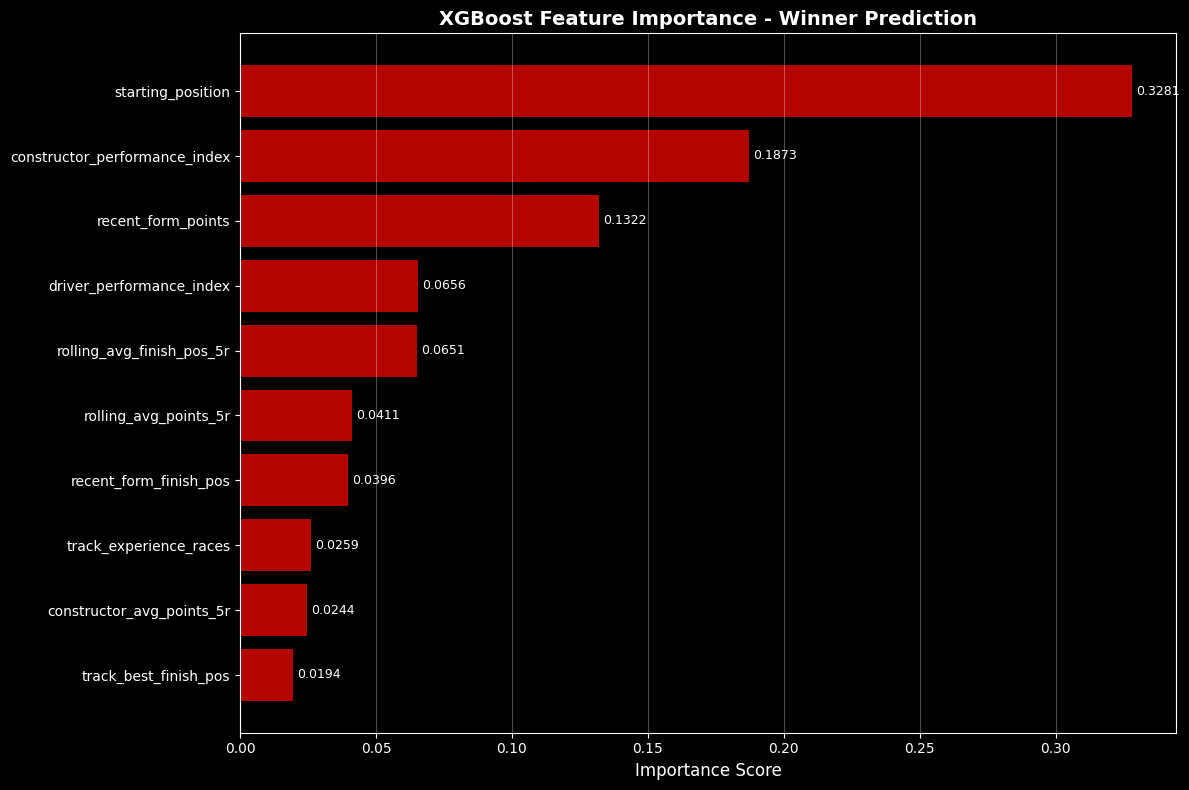


TOP 10 FEATURES FOR WINNER PREDICTION:
 1. starting_position                  : 0.3281
 2. constructor_performance_index      : 0.1873
 3. recent_form_points                 : 0.1322
 4. driver_performance_index           : 0.0656
 5. rolling_avg_finish_pos_5r          : 0.0651
 6. rolling_avg_points_5r              : 0.0411
 7. recent_form_finish_pos             : 0.0396
 8. track_experience_races             : 0.0259
 9. constructor_avg_points_5r          : 0.0244
10. track_best_finish_pos              : 0.0194


In [13]:
# Extract feature importance from the nested structure
if 'is_winner' in results and 'xgboost' in results['is_winner']:
    model_data = results['is_winner']['xgboost']
    
    # Check if we have metrics in the nested structure
    if isinstance(model_data, dict) and 'metrics' in model_data:
        importance = model_data['metrics'].get('feature_importance', {})
    elif isinstance(model_data, dict) and 'feature_importance' in model_data:
        importance = model_data['feature_importance']
    else:
        print("Could not find feature importance in results structure")
        importance = {}
    
    if importance:
        # Create DataFrame and sort
        imp_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
        imp_df = imp_df.sort_values('Importance', ascending=True)
        
        # Plot top 15 features
        fig, ax = plt.subplots(figsize=(12, 8))
        top_features = imp_df.tail(15)
        bars = ax.barh(top_features['Feature'], top_features['Importance'], color='#e10600', alpha=0.8)
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            ax.annotate(f'{width:.4f}',
                       xy=(width, bar.get_y() + bar.get_height() / 2),
                       xytext=(3, 0),
                       textcoords="offset points",
                       ha='left', va='center', fontsize=9)
        
        ax.set_xlabel('Importance Score', fontsize=12)
        ax.set_title('XGBoost Feature Importance - Winner Prediction', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        # Print top 10 features
        print("\n" + "="*60)
        print("TOP 10 FEATURES FOR WINNER PREDICTION:")
        print("="*60)
        for i, (feature, imp_value) in enumerate(list(importance.items())[:10], 1):
            print(f"{i:2d}. {feature:35s}: {imp_value:.4f}")
    else:
        print("No feature importance available")
else:
    print("XGBoost winner model not found in results")

In [14]:
from src.models.evaluate import ModelEvaluator

# Load test data and predictions
evaluator = ModelEvaluator()

# Example threshold analysis (would use actual test data)
print("=== THRESHOLD ANALYSIS ===")
print("\nOptimal thresholds for business use cases:")
print("- Conservative (High Precision): threshold > 0.7")
print("- Balanced (F1 Optimized): threshold ~ 0.5")
print("- Aggressive (High Recall): threshold < 0.3")

=== THRESHOLD ANALYSIS ===

Optimal thresholds for business use cases:
- Conservative (High Precision): threshold > 0.7
- Balanced (F1 Optimized): threshold ~ 0.5
- Aggressive (High Recall): threshold < 0.3


In [ ]:

from src.models.train import F1ModelTrainer
import pickle
from pathlib import Path

print('=' * 60)
print('TRAINING MODELS WITH FIXED TRAINER')
print('=' * 60)

trainer = F1ModelTrainer()
results = trainer.train_all_models(years=[2020, 2021, 2022, 2023, 2024, 2025])

print('\n' + '=' * 60)
print('VERIFYING SAVED MODELS')
print('=' * 60)

model_dir = Path('artifacts/models')
for model_file in model_dir.glob('*.pkl'):
    with open(model_file, 'rb') as f:
        bundle = pickle.load(f)
    
    is_valid = False
    if isinstance(bundle, dict):
        if 'model' in bundle and hasattr(bundle['model'], 'predict'):
            is_valid = True
            model_type = type(bundle['model']).__name__
            print(f' {model_file.name}: {model_type} (valid)')
        else:
            print(f'{model_file.name}: Invalid - missing model or no predict method')
    else:
        print(f' {model_file.name}: Not a dict - {type(bundle)}')

print('\n✅ Training complete!')


TRAINING MODELS WITH FIXED TRAINER
2026-05-17 17:12:36 [debug    ] sql_query_executing            parameters={'year_0': 2020, 'year_1': 2021, 'year_2': 2022, 'year_3': 2023, 'year_4': 2024, 'year_5': 2025} statement='\n        SELECT \n            f.*,\n            r.year,\n            r.round,\n            r.date as race_date\n        FROM driver_race_features f\n        JOIN races r ON f.race_id = r.race_id\n        WHE'
2026-05-17 17:12:43 [debug    ] database_transaction_committed
2026-05-17 17:12:43 [info     ] training_data_loaded           features=26 rows=2618 years=[2020, 2021, 2022, 2023, 2024, 2025]
2026-05-17 17:12:43 [info     ] SMOTE applied for winner: 3978 samples
2026-05-17 17:12:43 [info     ] SMOTE applied for top3: 3560 samples
2026-05-17 17:12:43 [info     ] features_prepared              features=26 test_size=524 train_size=2094
2026-05-17 17:12:43 [info     ] Training winner prediction models...
2026-05-17 17:12:43 [info     ] logistic_regression_trained    targe

d:\formula1-race-prediction-project\notebooks\..\src\models\train.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(X.median())


2026-05-17 17:12:43 [info     ] random_forest_trained          target=winner
2026-05-17 17:12:44 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_winner_20260517_141243.pkl target=winner


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:12:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 17:12:44 [info     ] xgboost_trained                target=winner
2026-05-17 17:12:44 [info     ] model_saved                    model=xgboost path=artifacts\models\xgboost_winner_20260517_141244.pkl target=winner
2026-05-17 17:12:44 [info     ] Training top3 prediction models...
2026-05-17 17:12:44 [info     ] logistic_regression_trained    target=top3
2026-05-17 17:12:44 [info     ] model_saved                    model=logistic_regression path=artifacts\models\logistic_regression_top3_20260517_141244.pkl target=top3
2026-05-17 17:12:45 [info     ] random_forest_trained          target=top3
2026-05-17 17:12:45 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_top3_20260517_141245.pkl target=top3


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:12:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 17:12:45 [info     ] xgboost_trained                target=top3
2026-05-17 17:12:45 [info     ] model_saved                    model=xgboost path=artifacts\models\xgboost_top3_20260517_141245.pkl target=top3
2026-05-17 17:12:45 [info     ] Training points prediction models...
2026-05-17 17:12:45 [info     ] linear_regression_trained     
2026-05-17 17:12:46 [info     ] model_saved                    model=linear_regression path=artifacts\models\linear_regression_points_20260517_141245.pkl target=points
2026-05-17 17:12:46 [info     ] random_forest_regressor_trained
2026-05-17 17:12:47 [info     ] model_saved                    model=random_forest path=artifacts\models\random_forest_points_20260517_141246.pkl target=points
2026-05-17 17:12:47 [info     ] pipeline_metrics               duration_seconds=11.263168 errors=[] pipeline_name=model_training records_failed=0 records_processed=0 status=completed success_rate=0
2026-05-17 17:12:47 [info     ] training_pipeline_complete 